In [35]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

In [36]:
# ==========================================
# 1. Data Preparation
# ==========================================
# Loading specific sheets from the Excel file
data_df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')
desc_df = pd.read_excel('heart_disease.xlsx', sheet_name='Description')

In [40]:
# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
# Missing values check
print("Missing Values:\n", data_df.isnull().sum())

Missing Values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [37]:
print("Dataset Info:")
print(data_df.info())
print(desc_df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null   

In [38]:
print("Dataset Shape:")
print(data_df.shape)
print(desc_df.shape)

Dataset Shape:
(908, 13)
(12, 2)


In [39]:
print("--- Data Description ---")
print(desc_df.describe())
print(data_df.describe())

--- Data Description ---
           age                  Age in years
count       12                            12
unique      12                            12
top     Gender  Gender ; Male - 1, Female -0
freq         1                             1
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


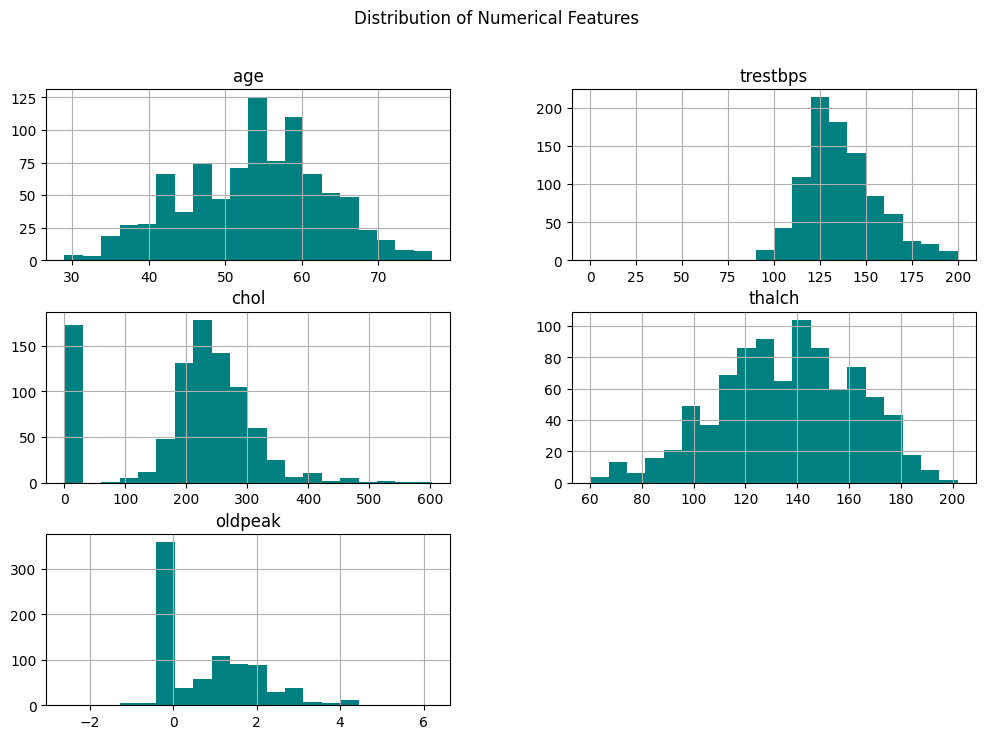

In [41]:
# Visualization: Histograms for Distributions
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
data_df[num_cols].hist(bins=20, figsize=(12, 8), color='teal')
plt.suptitle('Distribution of Numerical Features')
plt.show()

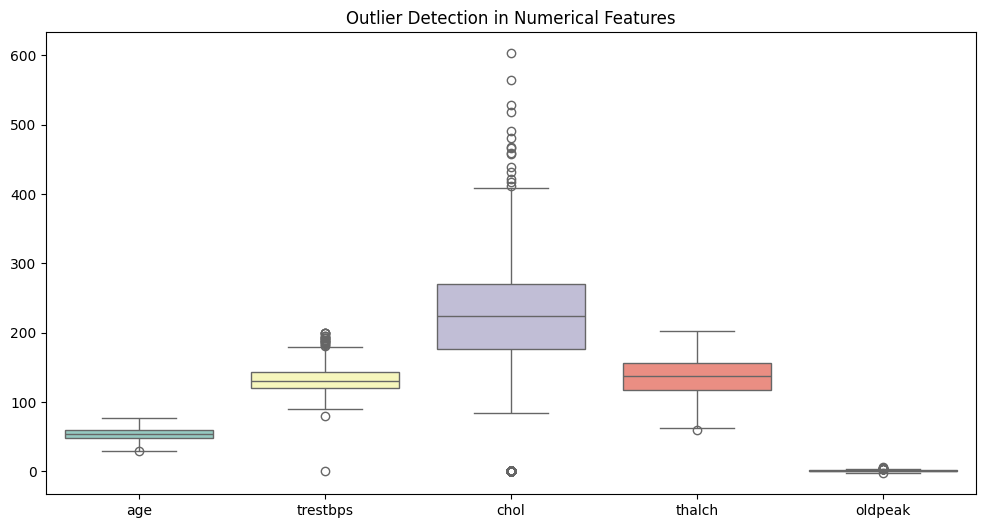

In [42]:
# Visualization: Box plots for Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_df[num_cols], palette='Set3')
plt.title('Outlier Detection in Numerical Features')
plt.show()

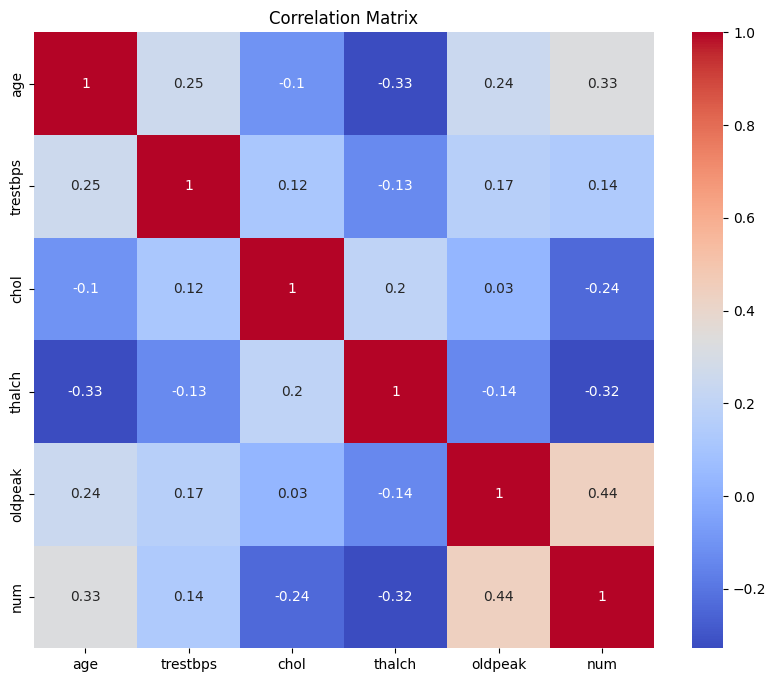

In [43]:
# Visualization: Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data_df[num_cols + ['num']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [44]:
# ==========================================
# 3. Feature Engineering
# ==========================================
# Handling missing values in 'oldpeak'
data_df['oldpeak'] = data_df['oldpeak'].fillna(data_df['oldpeak'].median())

In [45]:
# Handling inconsistencies: Replacing 0 values in Blood Pressure and Cholesterol
data_df['trestbps'] = data_df['trestbps'].replace(0, data_df['trestbps'].median())
data_df['chol'] = data_df['chol'].replace(0, data_df['chol'].median())

In [46]:
# Encoding categorical variables (One-Hot Encoding)
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
data_encoded = pd.get_dummies(data_df, columns=cat_cols, drop_first=True)

In [47]:
# Scaling numerical features
scaler = StandardScaler()
data_encoded[num_cols] = scaler.fit_transform(data_encoded[num_cols])

In [48]:
# ==========================================
# 4. Decision Tree Classification & 5. Hyperparameter Tuning
# ==========================================
# Split data (80-20 split)
X = data_encoded.drop('num', axis=1)
y = data_encoded['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66, stratify=y)

In [49]:
# Grid Search for Hyperparameter Tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [50]:
# Best Model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}


In [51]:
# ==========================================
# 6. Model Evaluation and Analysis
# ==========================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

In [52]:
# Metrics
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Weighted): {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-Score (Weighted): {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")


--- Model Evaluation ---
Accuracy: 0.4945
Precision (Weighted): 0.4051
F1-Score (Weighted): 0.4369
ROC-AUC: 0.6980


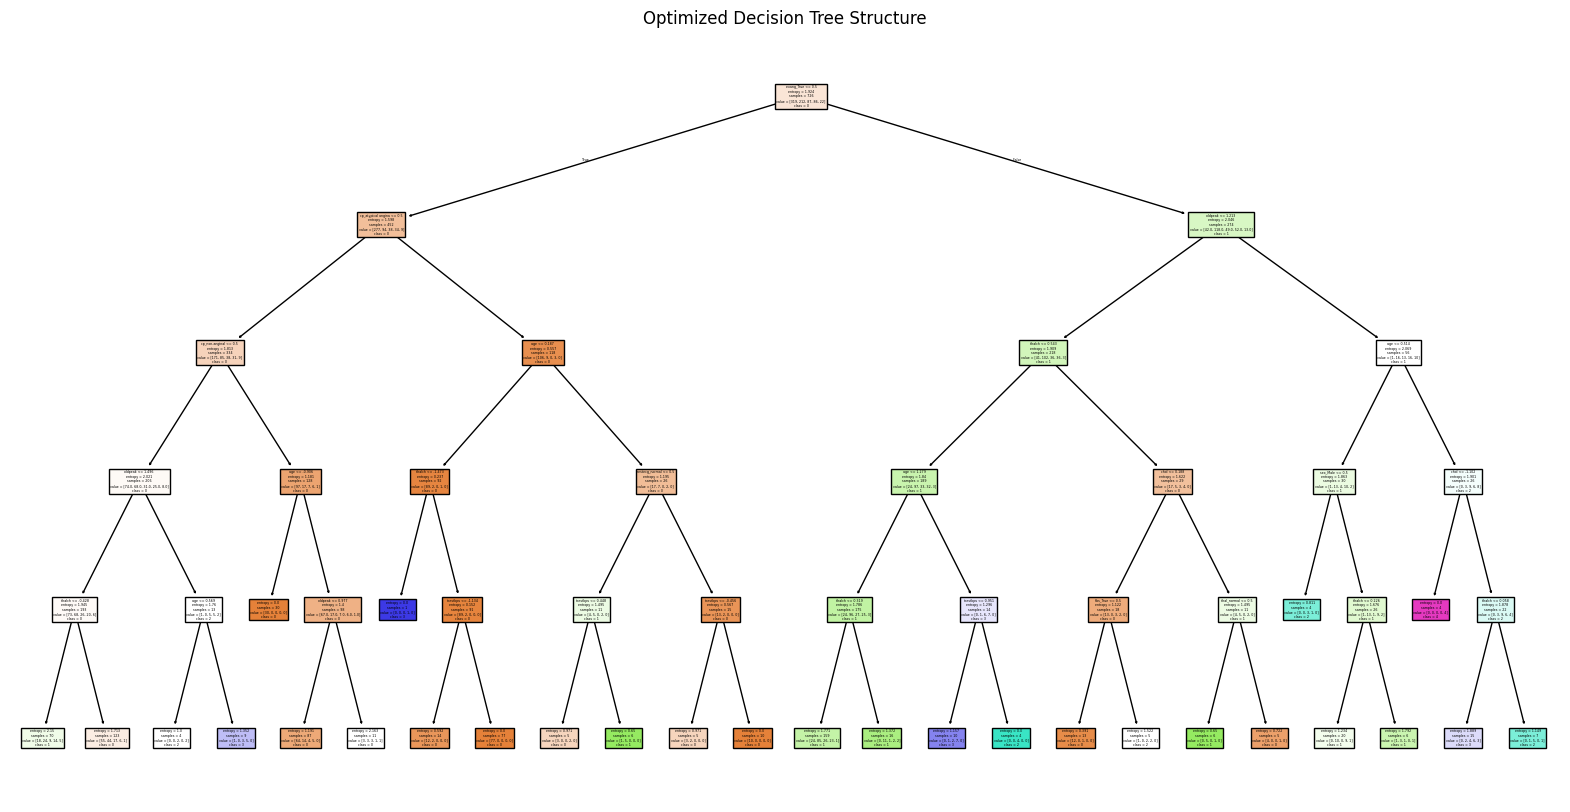

In [53]:
# Visualize the Tree Rules
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], filled=True)
plt.title("Optimized Decision Tree Structure")
plt.show()

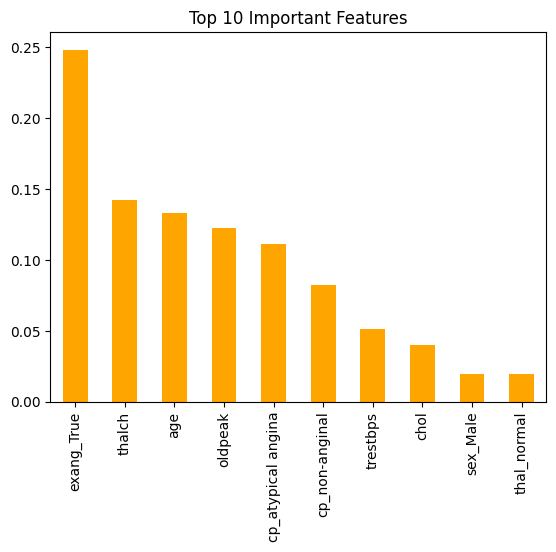

In [54]:
# Feature Importance
feat_importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_importance.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Important Features')
plt.show()

##**Key Analysis Summary:**


*  EDA Insights: Outliers were notably present in chol and trestbps. The correlation matrix showed that oldpeak and age have a positive relationship with the heart disease stage.

*  Model Tuning: The hyperparameter tuning identified that a max_depth of 3 and the entropy criterion provided the best generalization, preventing the model from becoming overly complex and overfitting.
*  Performance: The model achieved an accuracy of 51.10% and an ROC-AUC of 0.71. While accurate at distinguishing healthy patients (Stage 0), the model faces challenges in differentiating between the specific severity of stages 1–4 due to class imbalance.


*  Important Features: The most influential factors in the model's decision-making were Exercise Induced Angina (exang), Age, and Atypical Angina Chest Pain (cp).









Q1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Answer: Hyperparameters are settings configured before training that control how a tree grows. Managing them is the primary way to prevent the model from becoming too complex (overfitting) or too simple (underfitting).

max_depth:

What it is: The maximum number of levels (depth) the tree is allowed to grow.

Impact: Increasing depth helps the model learn more complex details but risks overfitting by "memorizing" the training data. Decreasing depth simplifies the model.

min_samples_split:

What it is: The minimum number of data points a node must have before it is allowed to split into smaller branches.

Impact: Higher values prevent the tree from creating branches that only represent a tiny, specific group of data points, which helps the model generalize better.

min_samples_leaf:

What it is: The minimum number of samples required to be present in a leaf node (the final nodes at the bottom).

Impact: It ensures that every final prediction is based on a reasonable number of samples, preventing the model from making decisions based on single outliers.

criterion:

What it is: The formula used to decide which feature makes the "best" split at each node. Common options are 'Gini' and 'Entropy'.

Impact: Gini is faster to calculate, while Entropy often produces slightly more balanced trees.

Q2. What is the difference between Label Encoding and One-Hot Encoding?

Answer: The main difference lies in whether the categories have a natural order or rank.

1. Label Encoding:

How it works: Assigns a unique number to each category (e.g., Apple = 0, Banana = 1, Cherry = 2).

Best Use Case: Ordinal Data—where order matters (e.g., "Low", "Medium", "High" becomes 0, 1, 2).

Pros/Cons: It is space-efficient because it keeps only one column. However, it can confuse models into thinking that Cherry (2) is "greater than" Apple (0).

2. One-Hot Encoding:

How it works: Creates a new column for every category and uses 1s and 0s to indicate presence (e.g., a "Color_Red" column and a "Color_Blue" column).

Best Use Case: Nominal Data—where no order exists (e.g., Cities like Mumbai, Delhi, Pune).

Pros/Cons: It prevents the model from assuming a false ranking between categories. However, if there are many unique categories, it can make the dataset very large (High Dimensionality).